# Data exploration

## Packages

In [105]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from pathlib import Path

import kagglehub

# Description of the dataset

The select dataset contains real-time IoT sensor data collected from industrial machines for predictive maintenance and anomaly detection in smart manufacturing systems. The dataset includes sensor readings, machine status, failure types, and a target column (maintenance_required), which indicates whether a machine requires maintenance.

**Dataset Contents**
- ``Timestamps`` – Time at which the sensor readings were recorded 
- ``Machine ID`` – Unique identifier for each machine
- ``Sensor Readings`` – Temperature, Vibration, Humidity, Pressure, Energy Consumption
- ``Machine Status`` – Indicates whether the machine is Idle, Running, or in Failure
- ``Anomaly Flags`` – Identifies extreme values in temperature and vibration
- ``Predicted Remaining Life`` – Estimated time before maintenance is needed
- ``Failure Type`` – The reason for machine failure (e.g., Overheating, Vibration Issue)
- ``Downtime Risk Score`` – Probability of machine breakdown
- ``Maintenance Required`` (maintenance_required) – Target column (0 = No, 1 = Yes)


**Purpose of This Dataset**
- Train Machine Learning Models for predictive maintenance
- Detect Anomalies in smart manufacturing environments
- Optimize IoT-driven industrial processes

## Download and load dataset

In [106]:
DATA_DIR = Path("../datasets/raw")
DATA_DIR.mkdir(parents=True, exist_ok=True)

csv_files = list(DATA_DIR.glob("*.csv"))

if csv_files:
    csv_path = csv_files[0]
    print(f"Dataset already exists: {csv_path}")

else:
    print("Dataset not found. Downloading from Kaggle...")

    dataset_path = kagglehub.dataset_download(
        "ziya07/smart-manufacturing-iot-cloud-monitoring-dataset",
        output_dir=str(DATA_DIR)
    )

    csv_files = list(Path(dataset_path).glob("*.csv"))

    if not csv_files:
        raise FileNotFoundError("No CSV file found in the downloaded dataset.")

    csv_path = csv_files[0]
    print(f"Dataset downloaded to: {csv_path}")

df = pd.read_csv(csv_path)

print(f"Dataset loaded: {df.shape}")

Dataset already exists: ../datasets/raw/smart_manufacturing_data.csv
Dataset loaded: (100000, 13)


## Quick dataset overview

In [3]:
print(f"\nDataset shape: {df.shape}")
print(f"Date range: {df.index.min()} to {df.index.max()}")


Dataset shape: (100000, 13)
Date range: 0 to 99999


In [4]:
print(f"\nFirst few rows:")
df.head()


First few rows:


,timestamp,machine_id,temperature,vibration,humidity,pressure,energy_consumption,machine_status,anomaly_flag,predicted_remaining_life,failure_type,downtime_risk,maintenance_required
0,2025-01-01 00:00:00,39,78.61,28.65,79.96,3.73,2.16,1,0,106,Normal,0.0,0
1,2025-01-01 00:01:00,29,68.19,57.28,35.94,3.64,0.69,1,0,320,Normal,0.0,0
2,2025-01-01 00:02:00,15,98.94,50.20,72.06,1.00,2.49,1,1,19,Normal,1.0,1
3,2025-01-01 00:03:00,43,90.91,37.65,30.34,3.15,4.96,1,1,10,Normal,1.0,1
4,2025-01-01 00:04:00,8,72.32,40.69,56.71,2.68,0.63,2,0,65,Vibration Issue,0.0,1


In [5]:
print(f"\nDataset info:")
df.info()


Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 13 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   timestamp                 100000 non-null  str    
 1   machine_id                100000 non-null  int64  
 2   temperature               100000 non-null  float64
 3   vibration                 100000 non-null  float64
 4   humidity                  100000 non-null  float64
 5   pressure                  100000 non-null  float64
 6   energy_consumption        100000 non-null  float64
 7   machine_status            100000 non-null  int64  
 8   anomaly_flag              100000 non-null  int64  
 9   predicted_remaining_life  100000 non-null  int64  
 10  failure_type              100000 non-null  str    
 11  downtime_risk             100000 non-null  float64
 12  maintenance_required      100000 non-null  int64  
dtypes: float64(6), int64(5), str(2)
memory us

In [6]:
print(f"\nBasic statistics:")
df.describe()


Basic statistics:


,machine_id,temperature,vibration,humidity,pressure,energy_consumption,machine_status,anomaly_flag,predicted_remaining_life,downtime_risk,maintenance_required
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,25.499330,75.015625,50.012270,54.995401,3.000405,2.747064,1.002050,0.089160,234.269160,0.089155,0.196970
std,14.389439,10.031884,14.985444,14.437960,1.152399,1.297865,0.446193,0.284976,150.063062,0.284961,0.397711
min,1.000000,35.550000,-17.090000,30.000000,1.000000,0.500000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,13.000000,68.267500,39.970000,42.520000,2.000000,1.630000,1.000000,0.000000,97.000000,0.000000,0.000000
50%,25.000000,75.060000,49.960000,54.980000,3.010000,2.740000,1.000000,0.000000,230.000000,0.000000,0.000000
75%,38.000000,81.750000,60.100000,67.500000,4.000000,3.870000,1.000000,0.000000,365.000000,0.000000,0.000000
max,50.000000,121.940000,113.800000,80.000000,5.000000,5.000000,2.000000,1.000000,499.000000,1.000000,1.000000


Based on the basic statistics we can separe which are numerical and categorical.

Numerical:
- temperature
- vibration
- humidity
- pressure
- energy_consumption
- downtime_risk
- predicted_remaining_life

Categorical:
- machine_id
- machine_status
- anomaly flag
- failure_type
- maintenance_required


In [7]:
numeric_cols = ['temperature', 
                'vibration', 
                'humidity', 
                'pressure', 
                'energy_consumption', 
                'predicted_remaining_life',
                'downtime_risk',]

categorical_cols = ['machine_id',
                    'machine_status',   
                    'anomaly_flag',
                    'failure_type',
                    'maintenance_required']


## Data cleaning and preprocessing

In [8]:
# Data cleaning: duplicates and missing values
# Duplicates
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")
if dupes > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Dropped duplicates. New shape:", df.shape)

# Missing values
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
print("\nMissing values per column (if any):")
display(missing)

Duplicate rows: 0

Missing values per column (if any):


Series([], dtype: int64)

From the dataset information, we can see that there are only two columns that do not contain integer or float values: timestamp and failure_type. Since the timestamp represents the hour of the day, we are going to encode the failure_type column instead.

In [9]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()
label_encoders = {}

col = 'failure_type'
le = LabelEncoder()

df_encoded[col] = le.fit_transform(df_encoded[col])
label_encoders[col] = le   
print(f"{col}: classes -> {le.classes_}") 

df_encoded.head()

failure_type: classes -> ['Electrical Fault' 'Normal' 'Overheating' 'Pressure Drop'
 'Vibration Issue']


,timestamp,machine_id,temperature,vibration,humidity,pressure,energy_consumption,machine_status,anomaly_flag,predicted_remaining_life,failure_type,downtime_risk,maintenance_required
0,2025-01-01 00:00:00,39,78.61,28.65,79.96,3.73,2.16,1,0,106,1,0.0,0
1,2025-01-01 00:01:00,29,68.19,57.28,35.94,3.64,0.69,1,0,320,1,0.0,0
2,2025-01-01 00:02:00,15,98.94,50.20,72.06,1.00,2.49,1,1,19,1,1.0,1
3,2025-01-01 00:03:00,43,90.91,37.65,30.34,3.15,4.96,1,1,10,1,1.0,1
4,2025-01-01 00:04:00,8,72.32,40.69,56.71,2.68,0.63,2,0,65,4,0.0,1


## Exploratory Data Analysis

In [10]:
def plot_distribution(df, column, bins=30):
    plt.figure(figsize=(10, 6))
    sns.histplot(df[column], bins=bins, stat='density', kde=True, color='skyblue')
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Density')
    plt.show()

def plot_barplot(df, column):
    counts = df[column].value_counts()
    plt.figure(figsize=(10, 6))
    sns.barplot(x=counts.index, y=counts.values, hue=counts.index, palette="hsv", legend=False)
    plt.title(f'Count of {column}')
    plt.xlabel(column)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()  

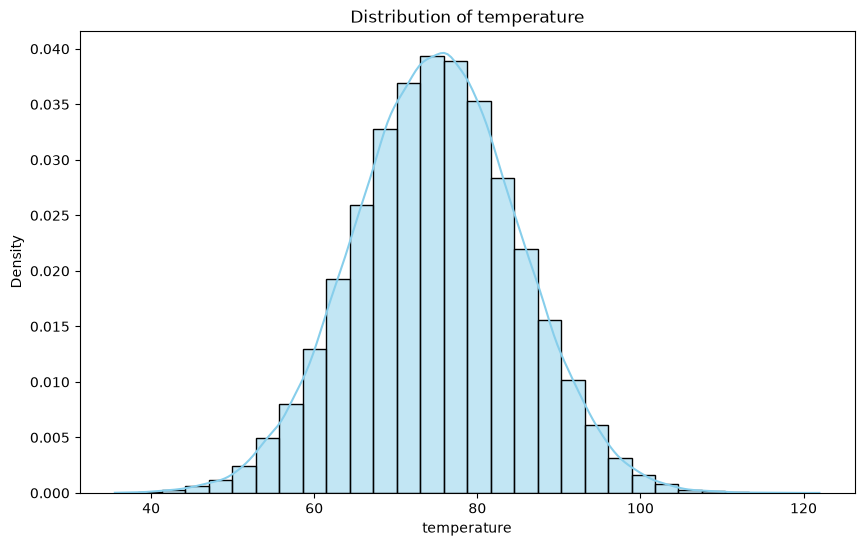

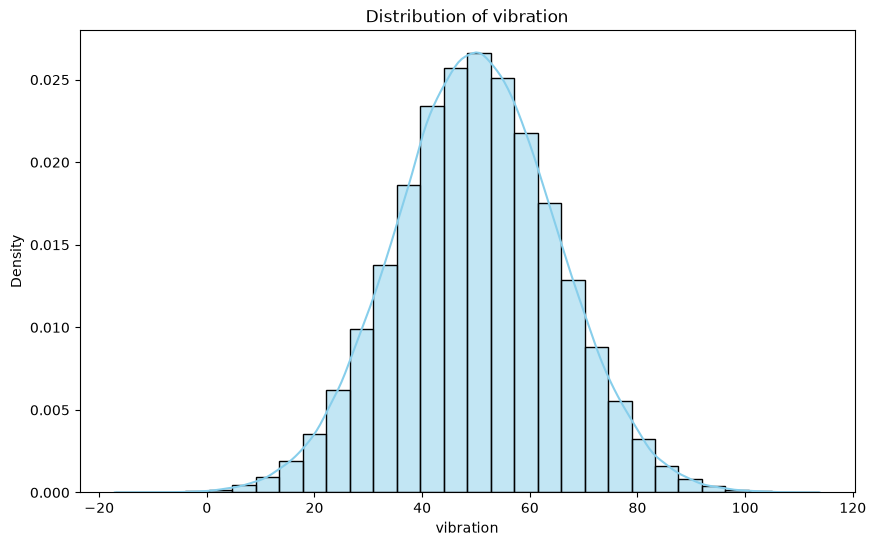

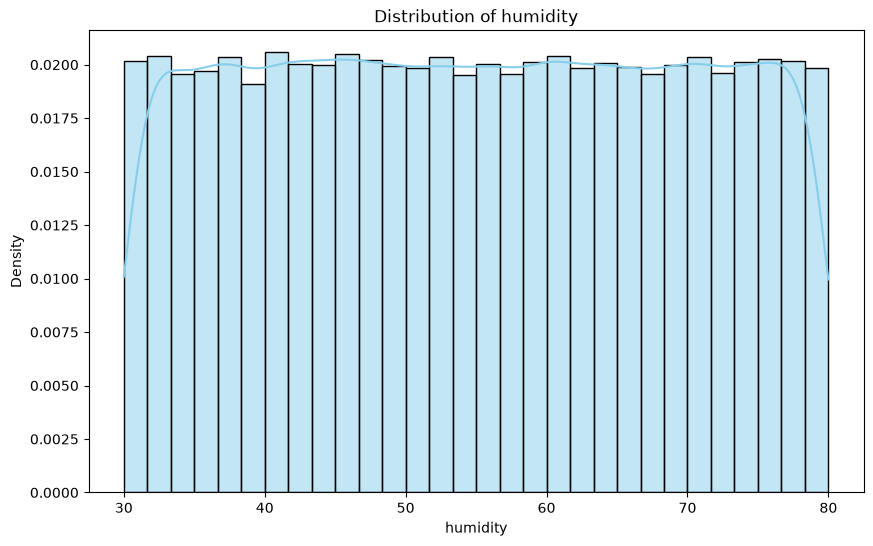

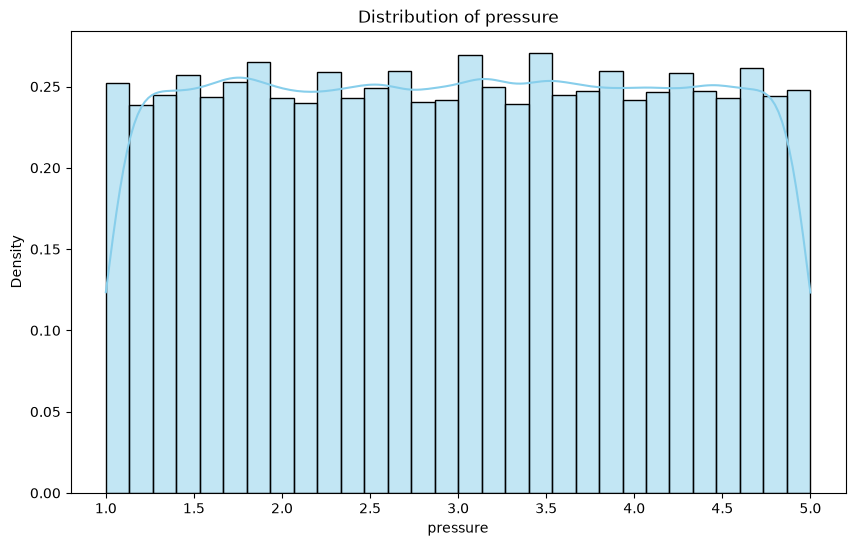

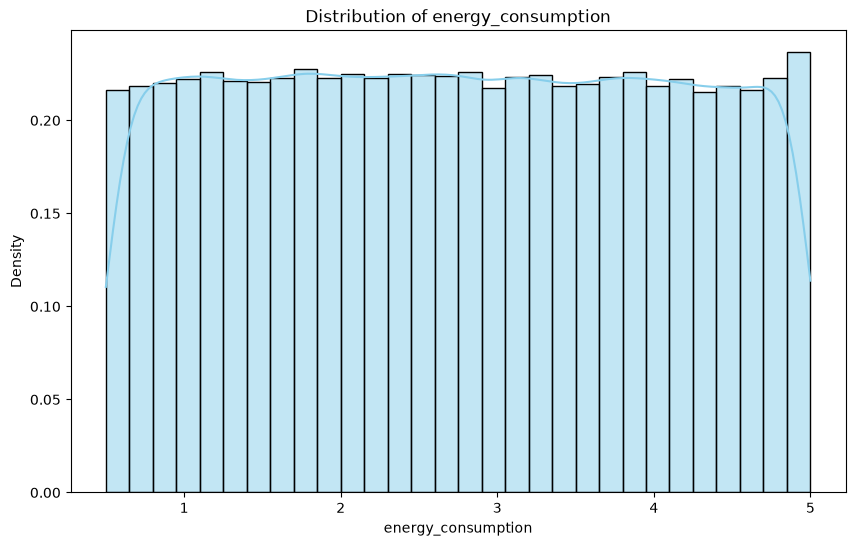

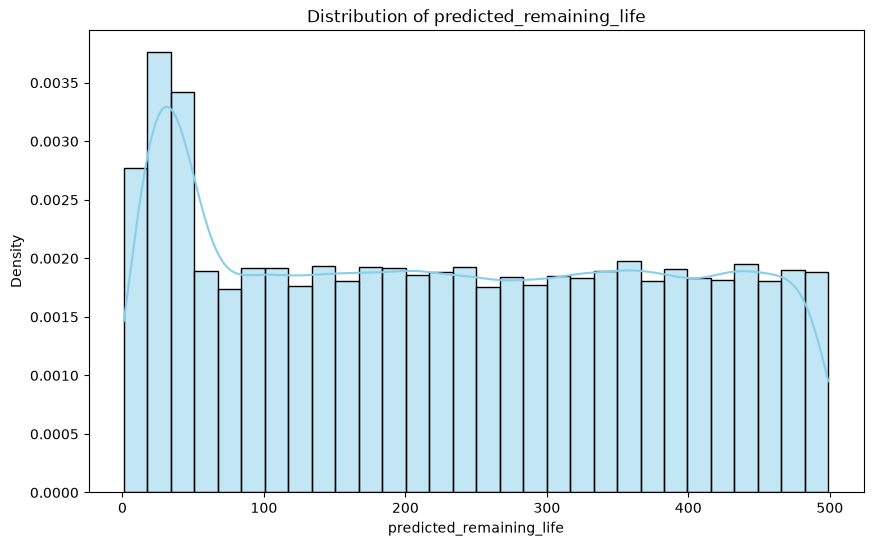

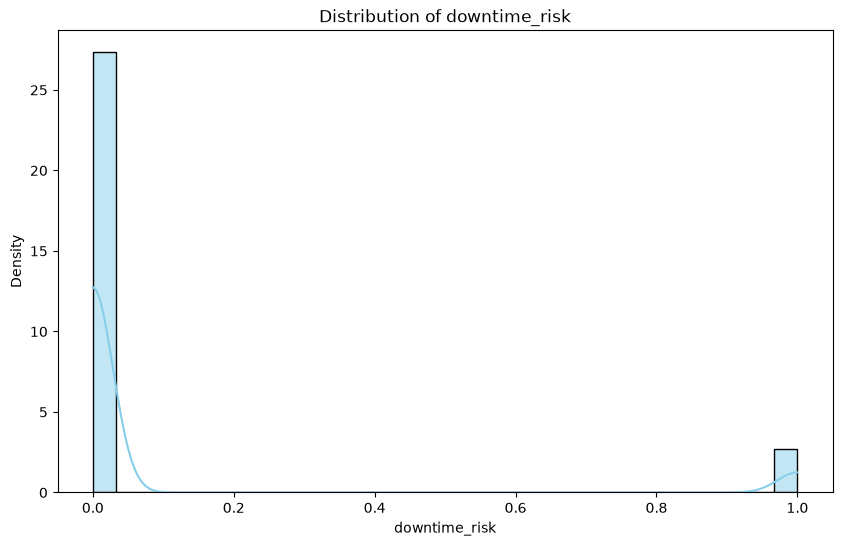

In [11]:
# Visualization 1: Distributions of numeric features
for col in numeric_cols:
    plot_distribution(df_encoded, col)

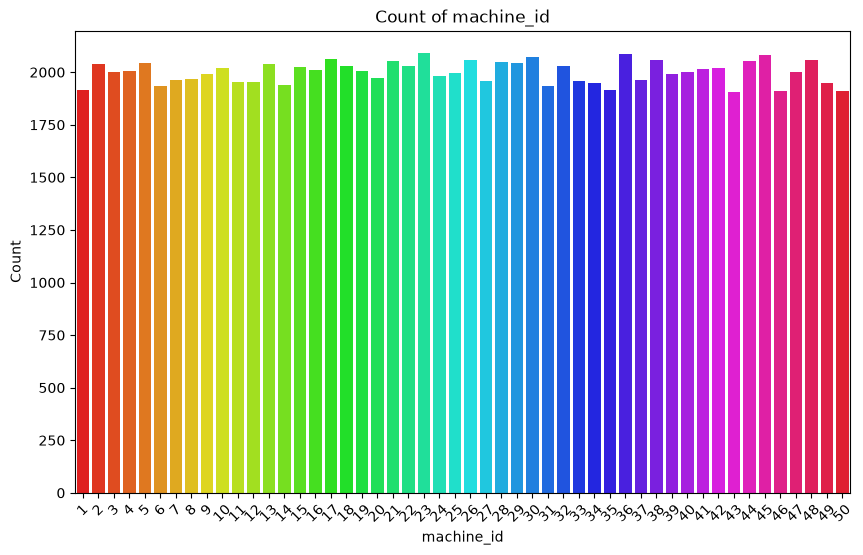

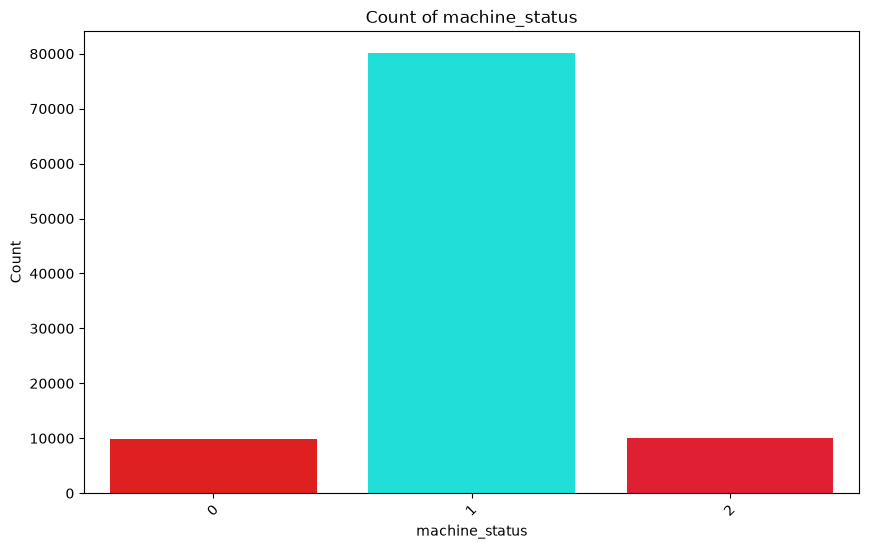

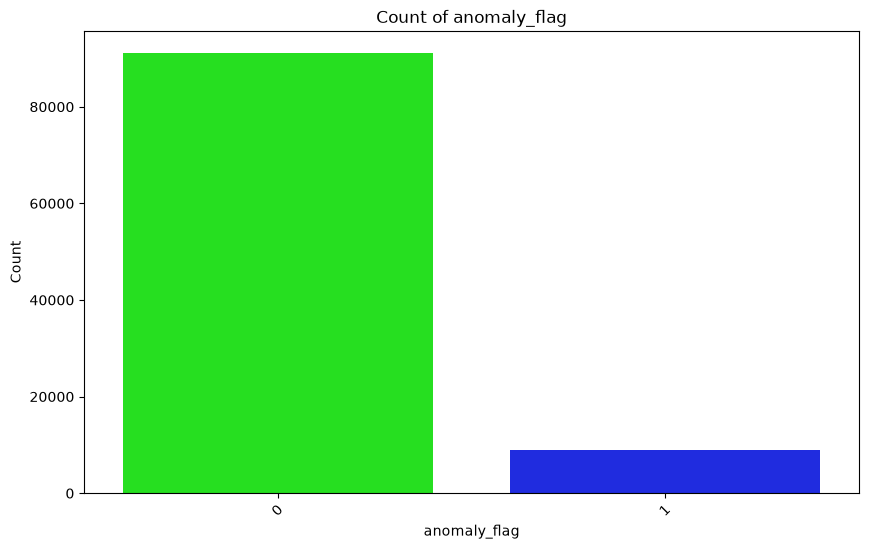

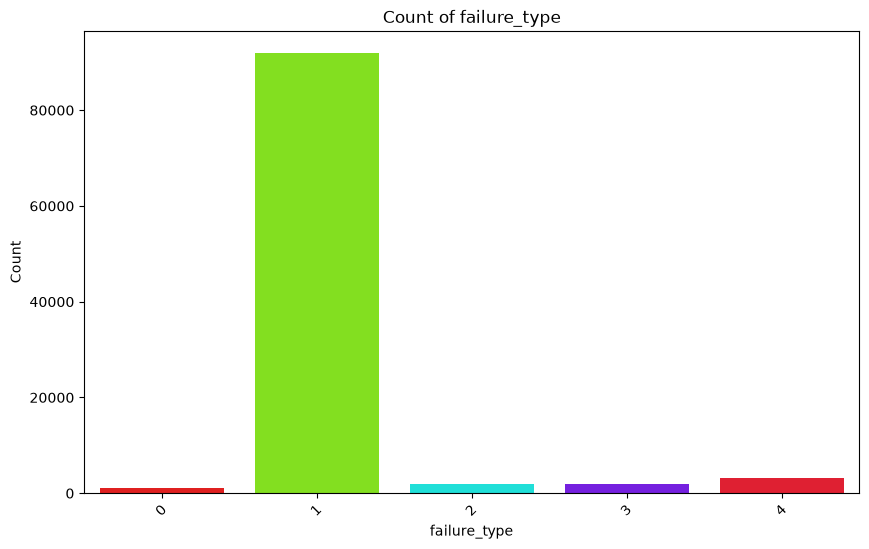

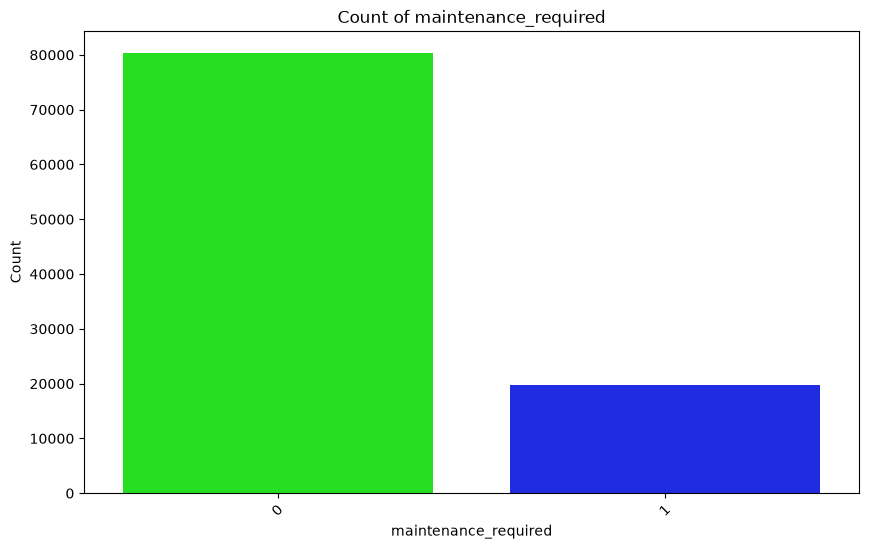

In [12]:
# Visualization 1: Distributions of categorical features
for col in categorical_cols:
    plot_barplot(df_encoded, col)

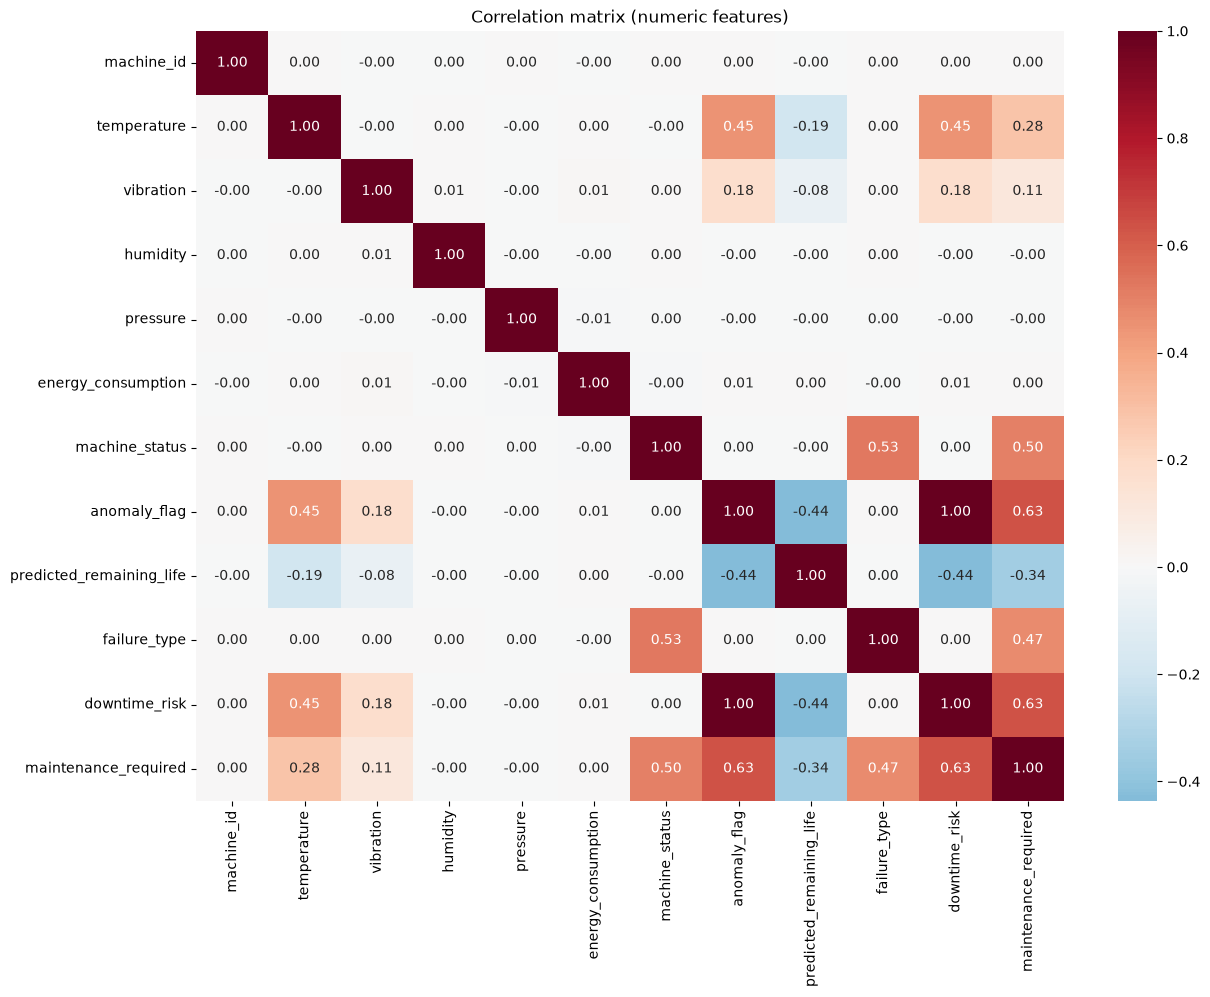

In [13]:
num_df = df_encoded.select_dtypes(include=[np.number])
plt.figure(figsize=(14,10))
sns.heatmap(num_df.corr(), annot=True, fmt=".2f", cmap='RdBu_r', center=0)
plt.title("Correlation matrix (numeric features)")
plt.show()

### Machine time series

In [90]:
def plot_time_series(df, column, machine_id):
    plt.figure(figsize=(14, 6))

    sns.lineplot(
        data=df,
        x="timestamp",
        y=column
    )

    plt.title(f"{column} of Machine {machine_id}")
    plt.xlabel("Time")
    plt.ylabel(column)

    # Show only a limited number of timestamps on the x-axis
    plt.xticks(rotation=45, ticks=df["timestamp"][::max(1, len(df) // 10)])

    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_time_interval_distribution(df, machine_id=None):
    plt.figure(figsize=(10, 6))
    sns.histplot(df["time_interval"], bins=30, stat='density', kde=True, color='lightcoral')
    plt.title(f'Time Interval Distribution for Machine {machine_id}' if machine_id is not None else 'Time Interval Distribution')
    plt.xlabel('Time Interval (seconds)')
    plt.ylabel('Density')
    plt.grid(True)
    plt.show()

In [100]:
df_encoded_machine_all = df_encoded.copy()

df_encoded_machine_all["timestamp"] = pd.to_datetime(
    df_encoded_machine_all["timestamp"]
)

df_encoded_machine_all = df_encoded_machine_all.sort_values(
    ["machine_id", "timestamp"]
)

df_encoded_machine_all["time_interval"] = (
    df_encoded_machine_all
    .groupby("machine_id")["timestamp"]
    .diff()
    .dt.total_seconds()
)

df_encoded_machine_all.head()

,timestamp,machine_id,temperature,vibration,humidity,pressure,energy_consumption,machine_status,anomaly_flag,predicted_remaining_life,failure_type,downtime_risk,maintenance_required,time_interval
97,2025-01-01 01:37:00,1,62.59,48.08,60.13,1.62,4.16,1,0,363,1,0.0,0,NaN
102,2025-01-01 01:42:00,1,70.88,68.67,50.57,1.05,2.36,1,0,111,1,0.0,0,300.0
133,2025-01-01 02:13:00,1,62.34,72.68,60.47,2.24,4.95,1,0,192,1,0.0,0,1860.0
139,2025-01-01 02:19:00,1,88.03,53.36,50.79,3.08,2.25,1,0,301,1,0.0,0,360.0
185,2025-01-01 03:05:00,1,79.39,49.44,56.99,2.54,2.76,1,0,127,1,0.0,0,2760.0


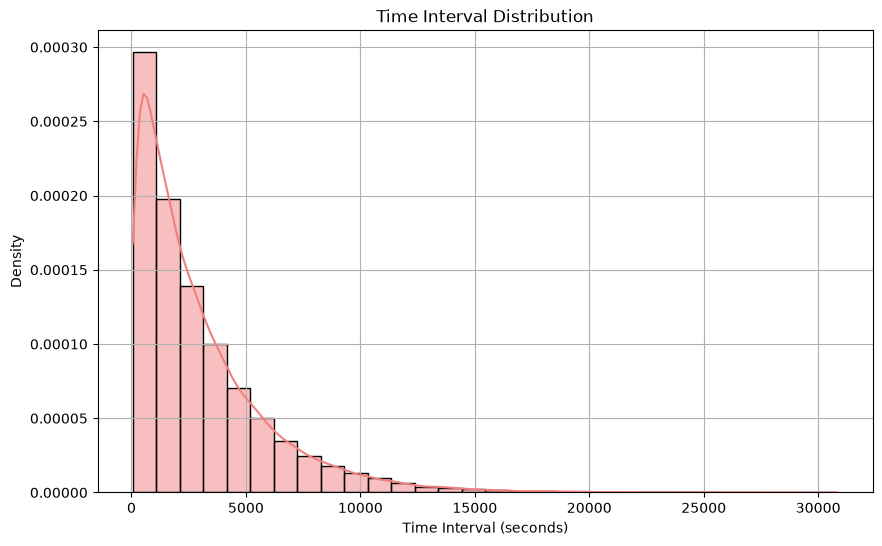

In [92]:
plot_time_interval_distribution(df_encoded_machine_all)

In [ ]:
machine_id = 1
df_encoded_machine = df_encoded[df_encoded['machine_id'] == machine_id]
df_encoded_machine = df_encoded_machine.drop(columns=['machine_id'])

# Calculate time intervals between consecutive timestamps for the selected machine in seconds
df_encoded_machine["time_interval"] = pd.to_datetime(df_encoded_machine["timestamp"]).diff().dt.total_seconds()
df_encoded_machine.iloc[0, df_encoded_machine.columns.get_loc("time_interval")] = 0  # Set the first time interval to 0 since there's no previous timestamp
df_encoded_machine.head()

,timestamp,temperature,vibration,humidity,pressure,energy_consumption,machine_status,anomaly_flag,predicted_remaining_life,failure_type,downtime_risk,maintenance_required,time_interval
97,2025-01-01 01:37:00,62.59,48.08,60.13,1.62,4.16,1,0,363,1,0.0,0,0.0
102,2025-01-01 01:42:00,70.88,68.67,50.57,1.05,2.36,1,0,111,1,0.0,0,300.0
133,2025-01-01 02:13:00,62.34,72.68,60.47,2.24,4.95,1,0,192,1,0.0,0,1860.0
139,2025-01-01 02:19:00,88.03,53.36,50.79,3.08,2.25,1,0,301,1,0.0,0,360.0
185,2025-01-01 03:05:00,79.39,49.44,56.99,2.54,2.76,1,0,127,1,0.0,0,2760.0


In [99]:
df_encoded_machine["time_interval"].describe()

count     1916.000000
mean      3126.043841
std       3084.608943
min          0.000000
25%        900.000000
50%       2100.000000
75%       4380.000000
max      24360.000000
Name: time_interval, dtype: float64

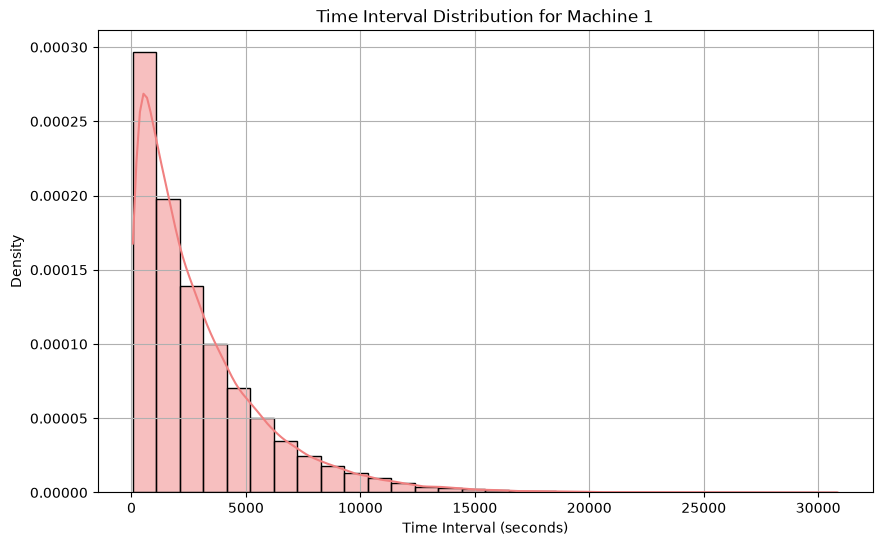

In [95]:
plot_time_interval_distribution(df_encoded_machine, machine_id)

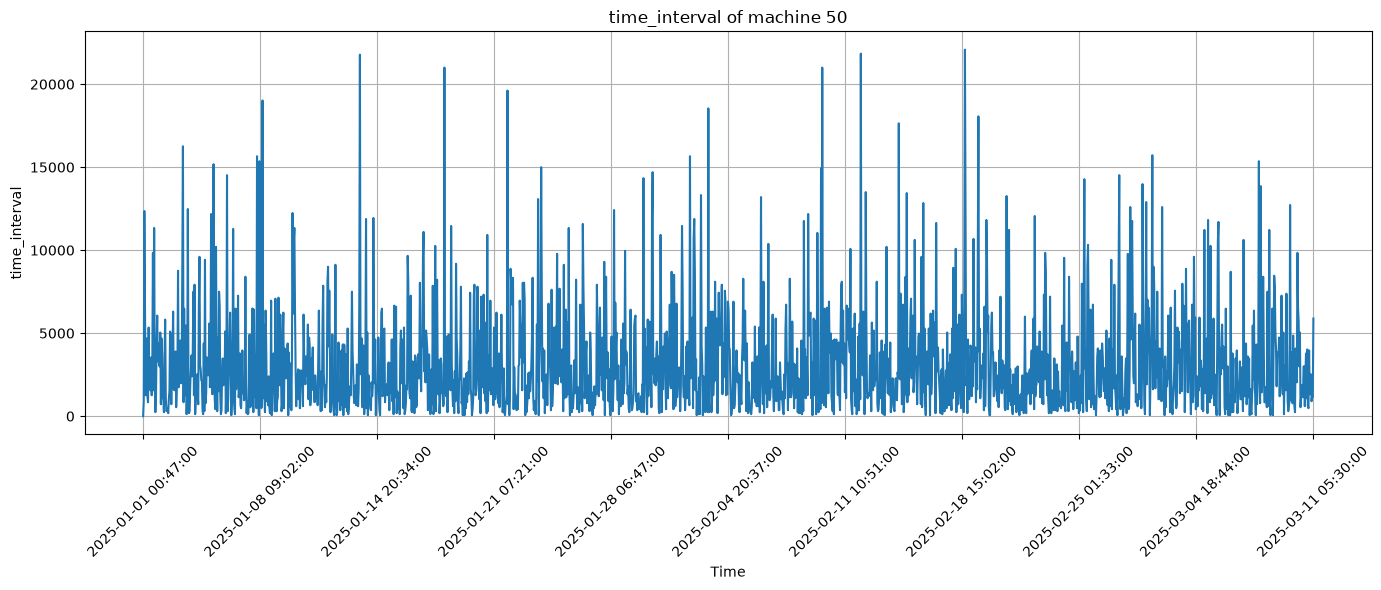

In [65]:
plot_time_series(df_encoded_machine, 'time_interval', machine_id)

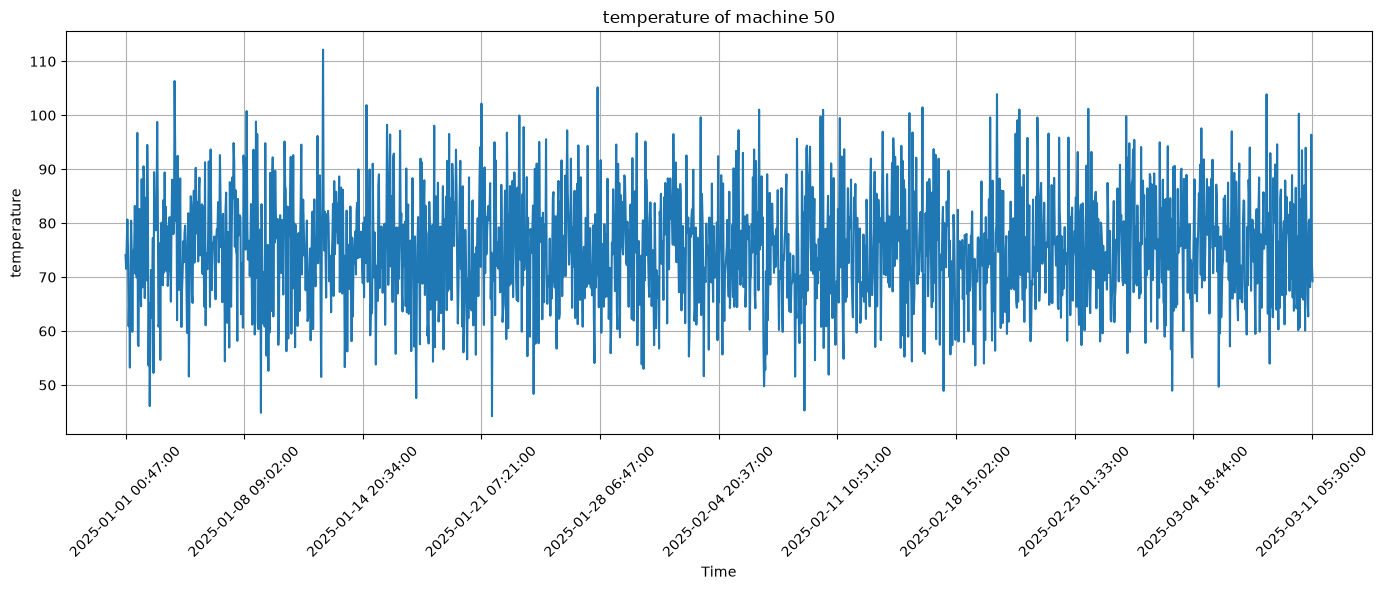

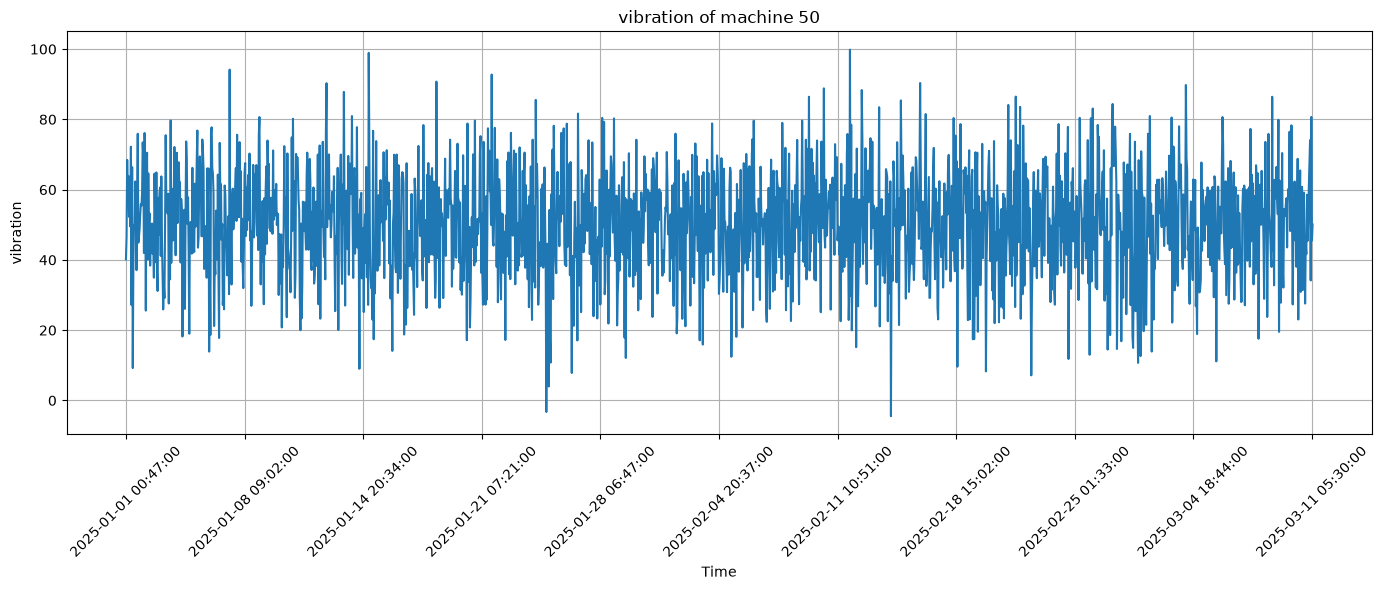

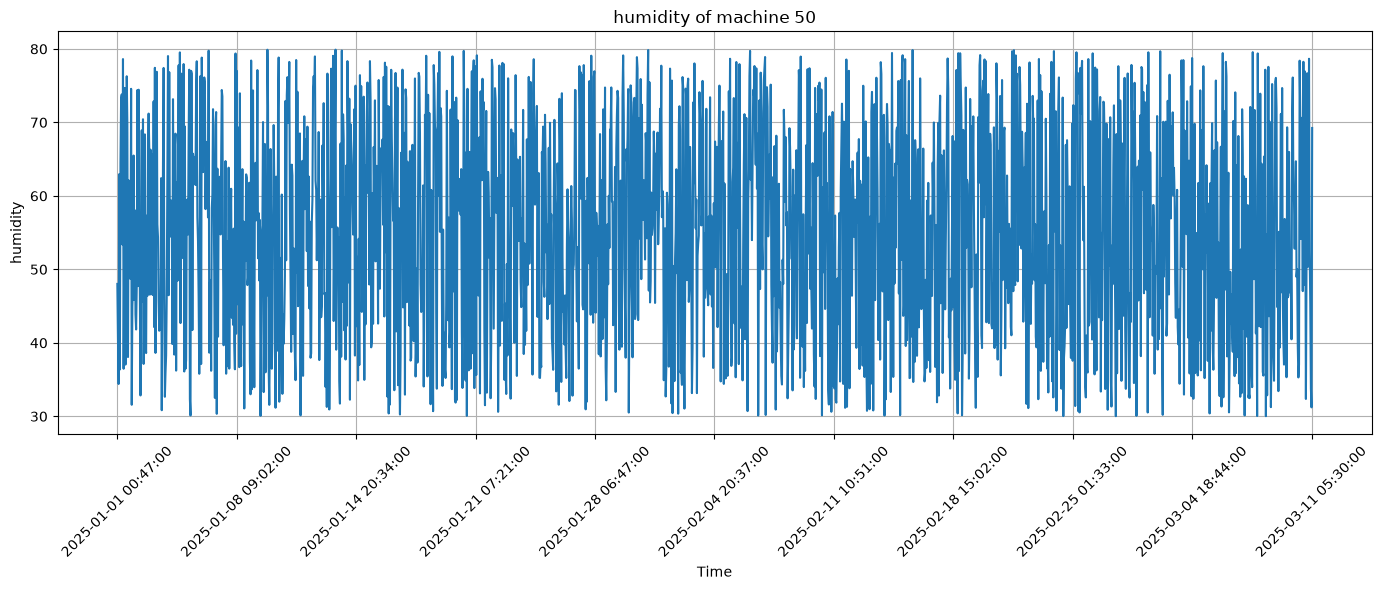

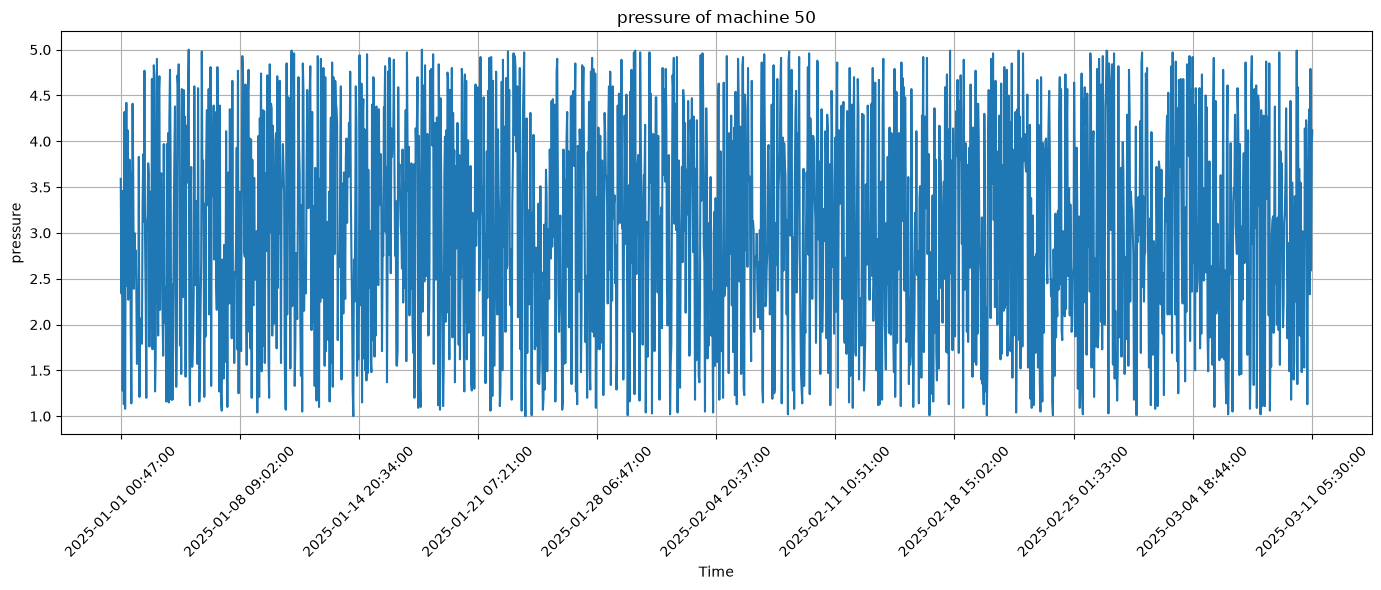

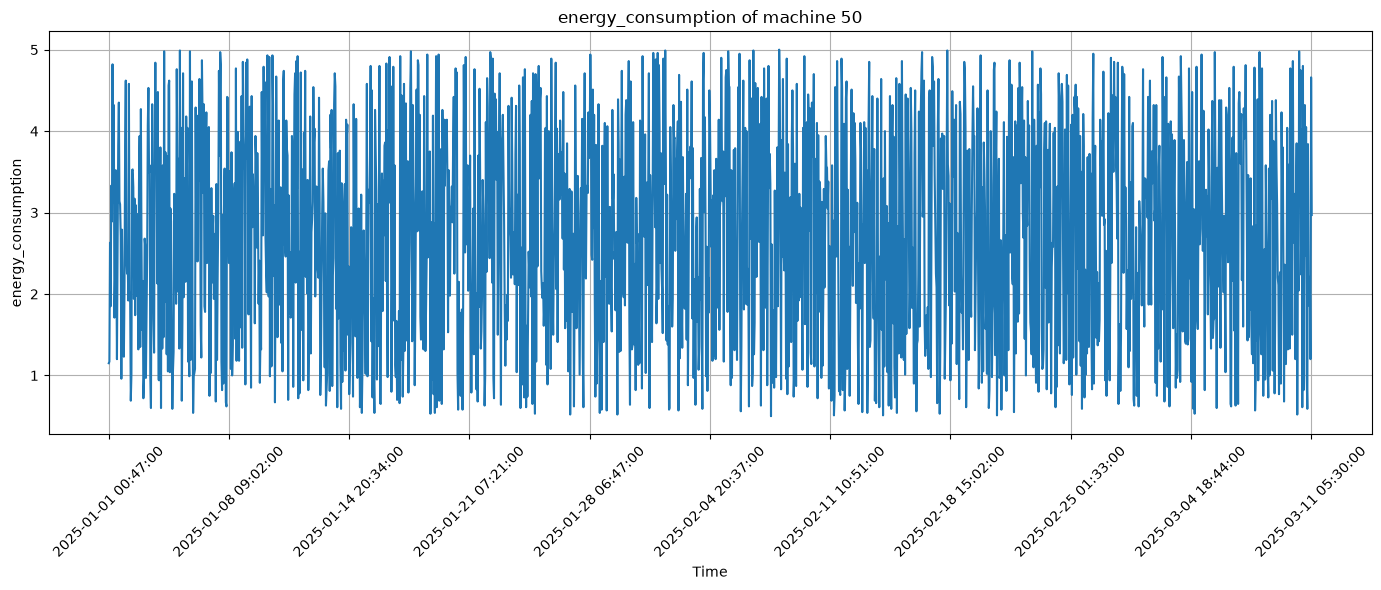

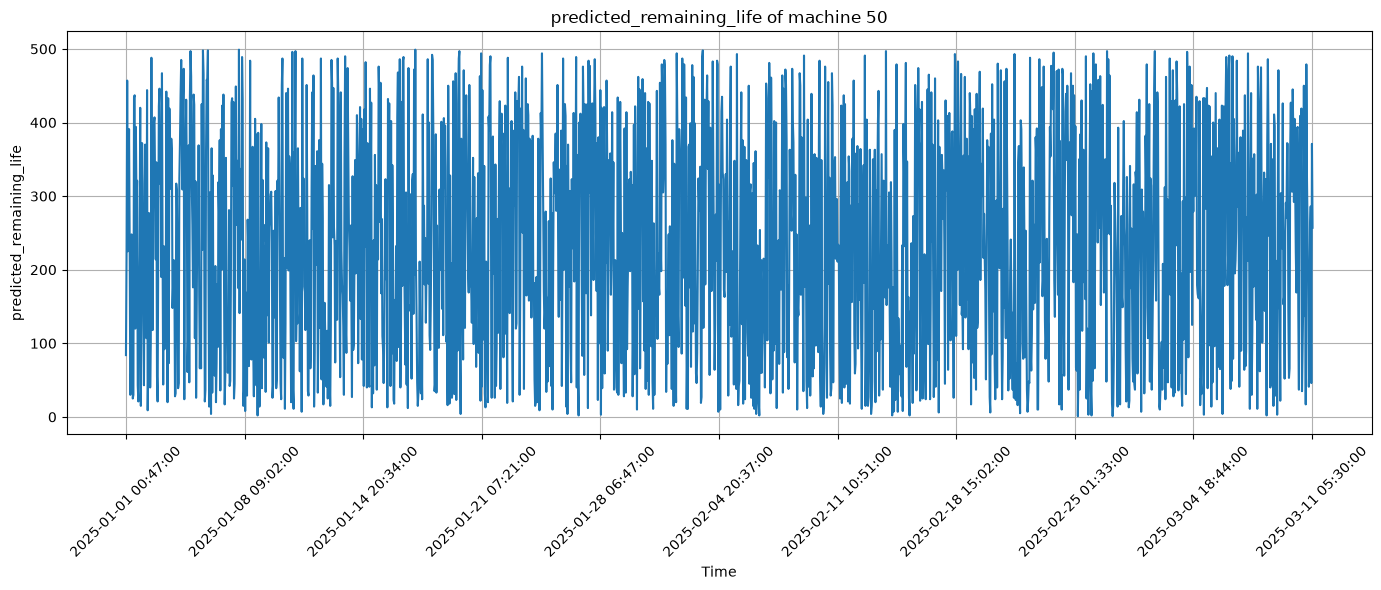

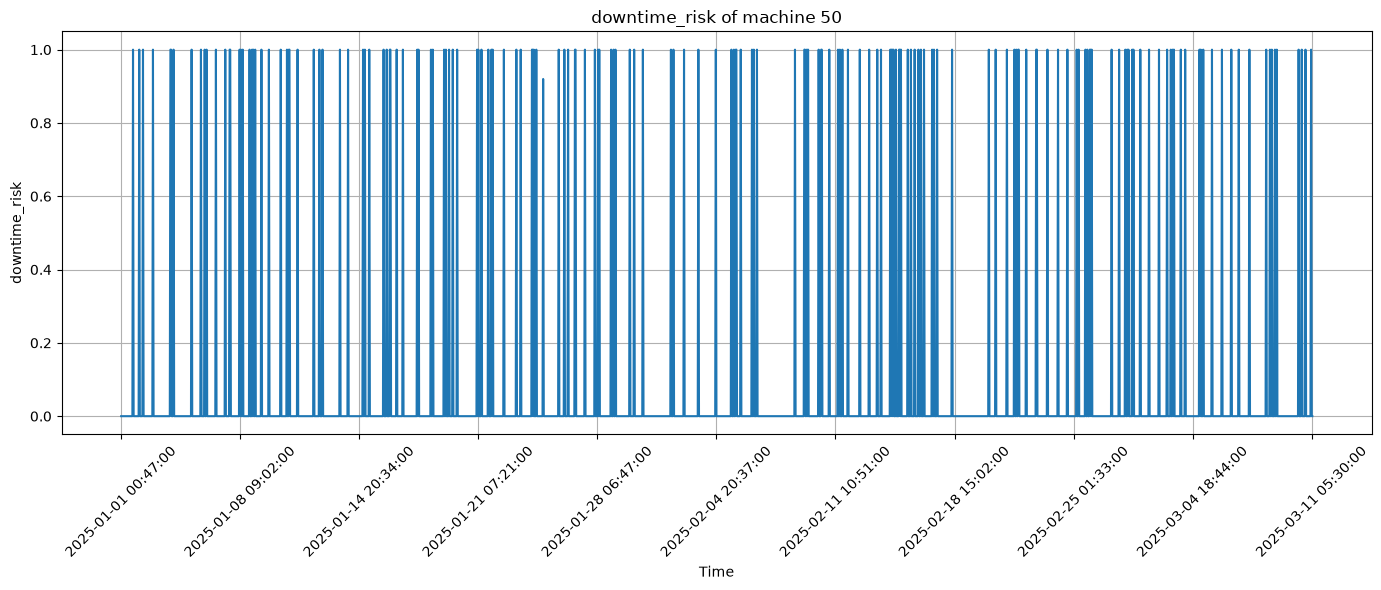

In [66]:
for col in numeric_cols:
    plot_time_series(df_encoded_machine, col, machine_id)

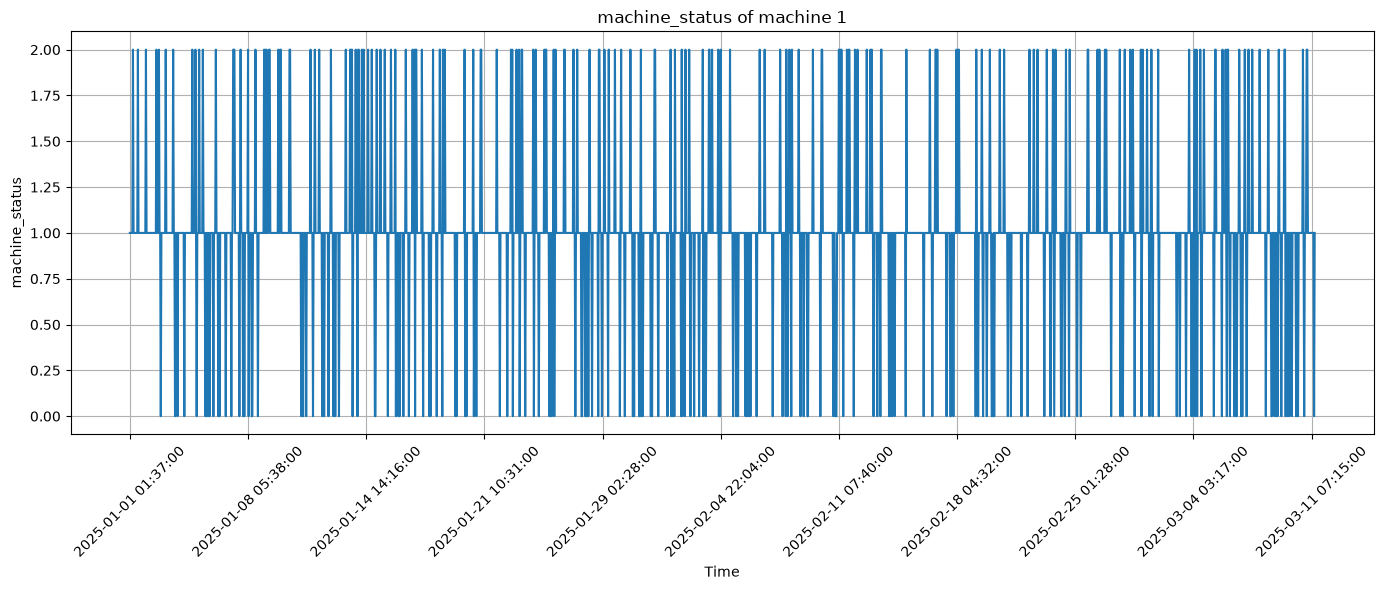

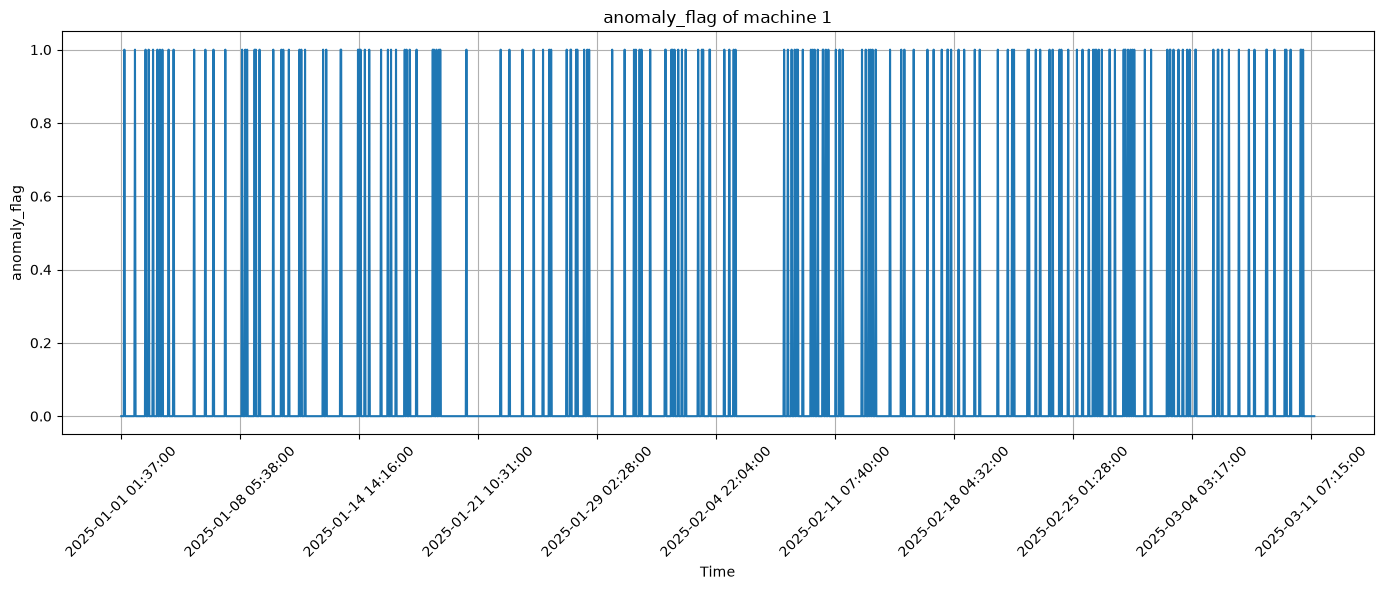

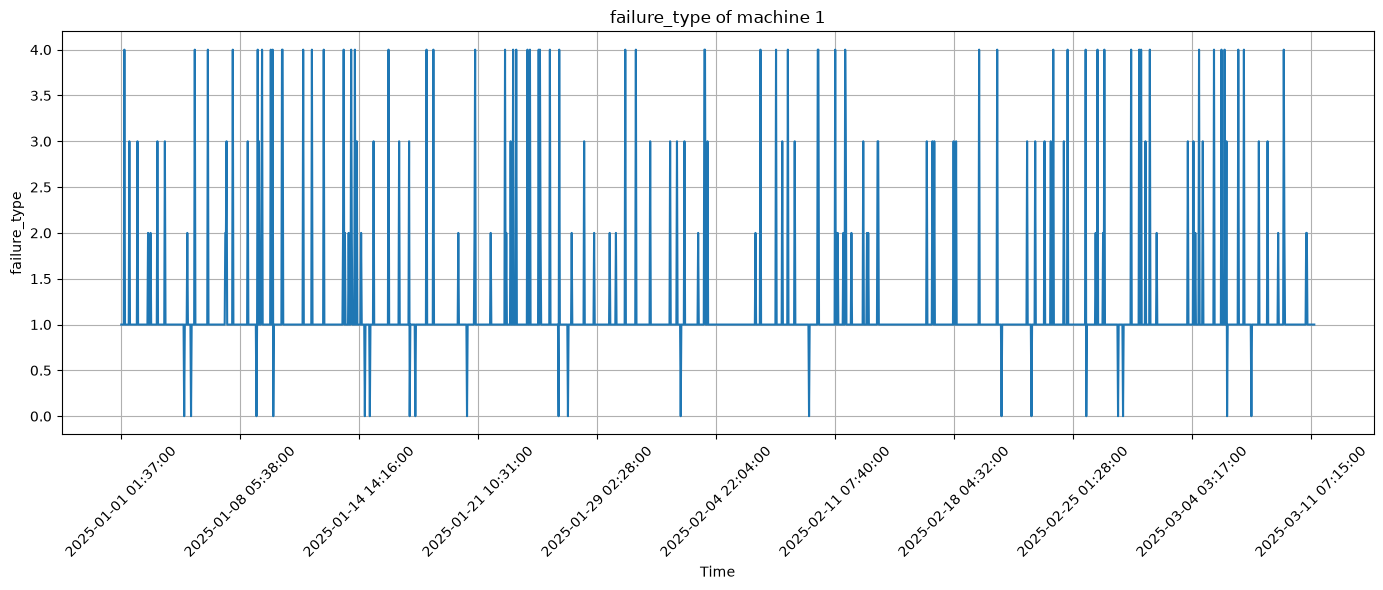

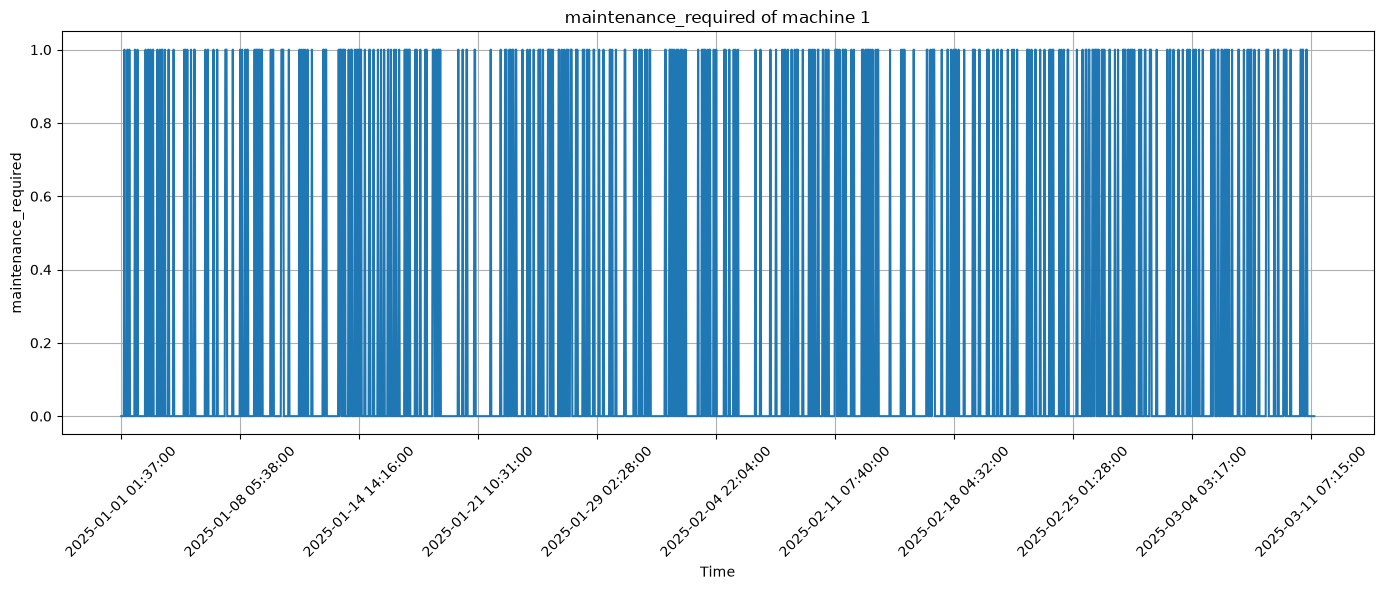

In [47]:
for col in categorical_cols[1:]:  # Skip 'machine_id' since it's already filtered
    plot_time_series(df_encoded_machine, col, machine_id)